# OUTLINE
1. Imports and Log-In
2. Open Segment Data and Limit to Type B/C Ocean
3. Get PACE L2m data
4. Data Grid algorithm: https://nasa.github.io/oceandata-notebooks/notebooks/oci/subsetting_with_harmony-py.html
5. Create one large geodataframe of chl_a data
6. Find LiDAR segment center points

In [1]:
"""

IMPORTS

"""
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as cx
from pyproj import Transformer
from matplotlib.ticker import FuncFormatter
import numpy as np
import earthaccess as ea
import pandas as pd
import glob
import xarray as xr
from harmony import (
    BBox,
    CapabilitiesRequest,
    Client,
    Collection,
    JobsRequest,
    LinkType,
    Request,
)
from datetime import datetime
from pathlib import Path
import rasterio
from IPython.display import JSON
from rasterio.enums import Resampling

# Toggle if needed
ea.login()
# ea.login(strategy='interactive', persist=True)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
""" 

Open Segment Data and Limit to Type B/C Ocean

"""

# photons_xy_ocean = gpd.read_parquet("data.photons_xy")
# segment_vars = gpd.read_parquet("data.FIXEDBINSsegment_vars")
# segment_vars = gpd.read_parquet("data.FIXEDBINS_2ksegment_vars")
segment_vars = gpd.read_parquet("data.FIXEDBINS_1ksegment_vars")

print(segment_vars["N_subsurface"].describe())
print(segment_vars["N_surface"].describe())


# Limit data to B/C ocean: Eidam et al., 2024 (and 2022). ARBITRARY # FOR NOW. AWAITING UPDATE
# print(segment_vars["N_subsurface"].describe())
type_a = segment_vars.loc[segment_vars["N_subsurface"] < 200]
""" ALERT """
segment_vars = segment_vars.loc[segment_vars["N_subsurface"] >= 200]
print(segment_vars["N_subsurface"].describe())


count    55863.000000
mean       255.642357
std        426.333217
min          1.000000
25%         47.000000
50%        137.000000
75%        270.000000
max       8077.000000
Name: N_subsurface, dtype: float64
count    55863.000000
mean       663.502372
std        976.669427
min          0.000000
25%        100.000000
50%        328.000000
75%        862.000000
max       9690.000000
Name: N_surface, dtype: float64
count    19403.000000
mean       583.831933
std        592.913434
min        200.000000
25%        260.000000
50%        373.000000
75%        663.000000
max       8077.000000
Name: N_subsurface, dtype: float64


In [3]:
""" 

Get time windows for PACE data

"""
# import pandas as pd

df = segment_vars.copy()
df["time"] = pd.to_datetime(df["time"])

delta = pd.Timedelta(hours=12)

windows = pd.DataFrame({
    "start": df["time"] - delta,
    "end": df["time"] + delta
}).sort_values("start")

windows

merged_windows = []

current_start = windows.iloc[0]["start"]
current_end = windows.iloc[0]["end"]

for i in range(1, len(windows)):
    start = windows.iloc[i]["start"]
    end = windows.iloc[i]["end"]

    if start <= current_end:  
        # overlap → extend window
        current_end = max(current_end, end)
    else:
        # no overlap → save previous
        merged_windows.append((current_start, current_end))
        current_start = start
        current_end = end

# append last window
merged_windows.append((current_start, current_end))
merged_windows_df = pd.DataFrame(merged_windows, columns=["start", "end"])

merged_windows_df

,start,end
0,2024-05-06 07:40:42.411540480,2024-05-07 07:40:46.043164928
1,2024-06-25 05:09:42.073373952,2024-06-26 05:09:58.141000704
2,2024-06-29 05:01:26.308510976,2024-06-30 05:01:42.334124800
3,2024-07-03 04:52:50.846547968,2024-07-04 04:53:00.710508800
4,2024-07-14 16:22:48.427340544,2024-07-15 16:22:55.524375552
...,...,...
110,2026-01-28 01:26:15.726781952,2026-01-29 01:26:27.814233088
111,2026-02-12 12:47:47.641026816,2026-02-13 12:48:05.022392576
112,2026-02-16 12:39:34.029153024,2026-02-17 12:39:49.623235328
113,2026-02-18 00:19:00.257221120,2026-02-19 00:19:13.244884224


In [4]:
# """

# Get PACE l2m data jobs (PART 1). Uncomment if Needde

# """
# auth = ea.login()
# harmony_client = Client(token=ea.get_edl_token())
# capabilities_request = CapabilitiesRequest(short_name="PACE_OCI_L2_BGC")
# capabilities = harmony_client.submit(capabilities_request)
# print(capabilities)

# # build and submit a request
# # request = JobsRequest(labels=["help-hub-tutorial"])
# # JSON(response)

# requests = []

# LAT_MIN = 33.70
# LAT_MAX = 34.80
# LON_MIN = -78.30
# LON_MAX = -75.30

# BOUNDING_BOX = (LON_MIN, LAT_MIN, LON_MAX, LAT_MAX) 

# for _, row in merged_windows_df.iterrows():
#     req = Request(
#         collection=Collection(id="PACE_OCI_L2_BGC"),
#         spatial=BBox(LON_MIN, LAT_MIN, LON_MAX, LAT_MAX),
#         temporal={
#             "start": pd.to_datetime(row["start"]).to_pydatetime(),
#             "stop": pd.to_datetime(row["end"]).to_pydatetime()
#         },
#         variables=["geophysical_data/chlor_a"],
#         labels={}
#     )
#     requests.append(req)

# len(requests)


# ### submit requests:
# jobs = []

# jobs = []
# failed = []

# for r in requests:
#     try:
#         job = harmony_client.submit(r)
#         jobs.append(job)
#     except Exception as e:
#         failed.append((r, str(e)))

# print(str(len(failed)) + " out of " + str(len(requests)) + " time windows (+/- 12 hrs) did not have PACE flyover")


In [5]:
""" Download PACE data: PART 2 UNCOMMENT IF NEEDED """

### Download PACE data ###

# output_dir = "DATA/PACE_l2_NC"
# # os.makedirs(output_dir, exist_ok=True)

# downloaded_paths = []

# for job_id in jobs:
#     try:
#         harmony_client.wait_for_processing(job_id, show_progress=True)
#         futures = harmony_client.download_all(job_id, directory=output_dir, overwrite=True)

#         for future in futures:
#             filename = future.result()   # blocks until this file finishes downloading
#             downloaded_paths.append(filename)

#     except Exception as e:
#         print(f"Job {job_id} failed:", e)

# print(f"Downloaded {len(downloaded_paths)} files")


# ### get rid of non-unique values

# seen = set()
# unique_files = []

# for path in downloaded_paths:
#     name = Path(path).name

#     if name not in seen:
#         seen.add(name)
#         unique_files.append(path)

' Download PACE data: PART 2 UNCOMMENT IF NEEDED '

In [6]:
""" 

Grid L2m data

"""

# Via: https://nasa.github.io/oceandata-notebooks/notebooks/oci/subsetting_with_harmony-py.html
from aux_fx import grid_data

In [7]:
""" 

Form a gridded geodataframe of chlorophyll

"""


import xarray as xr


files = glob.glob("DATA/PACE_l2_NC/*.nc")

dfs = []

for file in files:
    try:
        swath_time = pd.to_datetime(
            Path(file).stem.split(".")[1],
            format="%Y%m%dT%H%M%S"
        )

        dt = xr.open_datatree(file)
        ds = xr.merge(dt.to_dict().values())
        ds = ds.set_coords(("longitude", "latitude"))

        x = grid_data(ds, 0.02)

        # Convert to DataFrame
        df = (
            x["chlor_a"]
            .to_dataframe()
            .reset_index()
            .dropna(subset=["chlor_a"])
        )

        df["swath_time"] = swath_time

        dfs.append(df)

    except Exception as e:
        print(f"Skipping {file}: {e}")

df = pd.concat(dfs, ignore_index=True)

# Convert to GeoDataFrame
chl_a_gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.longitude, df.latitude),
    crs="EPSG:4326",
)

Skipping DATA/PACE_l2_NC/248702566_PACE_OCI.20250120T163216.L2.OC_BGC.V3_2_geophysical_data_chlor_a_subsetted.nc: Cannot invert geotransform


In [8]:
"""

Find Segment Center Points

"""
print(segment_vars.shape)
def get_segment_centers(segment_vars):
    segment_vars_centered = segment_vars.to_crs(epsg=4326)
    midpoints = segment_vars_centered.geometry.interpolate(0.5, normalized=True)
    segment_vars_centered["lon"] = midpoints.x
    segment_vars_centered["lat"] = midpoints.y
    segment_vars_centered["lidar_date"] = pd.to_datetime(segment_vars_centered["time"])
    
    return segment_vars_centered


(19403, 15)


In [9]:
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree

def match_chl_to_segments(segment_vars, chl_a_gdf, tolerance_deg, tolerance_time):
    """
    True nearest-neighbor matchup in (lon, lat, time) space using a KD-tree
    over the actual chl_a point observations (no gridding/xarray involved).
    """
    segment_vars_centered = get_segment_centers(segment_vars)

    # --- prep chl points ---
    valid = chl_a_gdf["chlor_a"].notna()
    chl_lon = chl_a_gdf.loc[valid, "longitude"].values
    chl_lat = chl_a_gdf.loc[valid, "latitude"].values
    chl_time = pd.to_datetime(chl_a_gdf.loc[valid, "swath_time"]).values
    chl_val  = chl_a_gdf.loc[valid, "chlor_a"].values

    # convert time to seconds (float) relative to some epoch, so it can share
    # a distance metric with degrees -- scale it so the time tolerance
    # corresponds to a comparable "distance" unit
    epoch = chl_time.min()
    chl_time_sec = (chl_time - epoch) / np.timedelta64(1, "s")

    tol_time_sec = pd.Timedelta(tolerance_time).total_seconds()
    # scale factor: make tolerance_time equivalent to tolerance_deg in the tree metric
    time_scale = tolerance_deg / tol_time_sec

    chl_points = np.column_stack([chl_lon, chl_lat, chl_time_sec * time_scale])
    tree = cKDTree(chl_points)

    # --- prep segment query points ---
    seg_lon = segment_vars_centered["lon"].values
    seg_lat = segment_vars_centered["lat"].values
    seg_time = pd.to_datetime(segment_vars_centered["lidar_date"]).values
    seg_time_sec = (seg_time - epoch) / np.timedelta64(1, "s")

    query_points = np.column_stack([seg_lon, seg_lat, seg_time_sec * time_scale])

    # single nearest neighbor in true joint space
    dist, idx = tree.query(query_points, k=1)

    matched_lon = chl_lon[idx]
    matched_lat = chl_lat[idx]
    matched_time = chl_time[idx]
    matched_val = chl_val[idx]

    lon_dist = np.abs(seg_lon - matched_lon)
    lat_dist = np.abs(seg_lat - matched_lat)
    time_dist = np.abs(seg_time - matched_time)

    too_far = (
        (lon_dist > tolerance_deg)
        | (lat_dist > tolerance_deg)
        | (time_dist > np.timedelta64(int(tol_time_sec), "s"))
    )

    n_too_far = too_far.sum()
    if n_too_far > 0:
        print(f"Masking {n_too_far} segments beyond tolerance ({tolerance_deg}° or {tolerance_time})")

    matched_val = matched_val.astype(float)
    matched_val[too_far] = np.nan

    segment_vars_centered["chl_a"] = matched_val
    segment_vars_centered["chl_lon_dist"] = lon_dist
    segment_vars_centered["chl_lat_dist"] = lat_dist
    segment_vars_centered["chl_time_dist"] = time_dist

    return segment_vars_centered
tolerance_deg = 0.02
tolerance_time = "12h"
matchup_df = match_chl_to_segments(segment_vars, chl_a_gdf, tolerance_deg, tolerance_time)
matchup_df['chl_a'].describe()


# Filter the DataFrame to keep rows where 'chl_a' is not NaN and where photon amounts are possible given ATL03's spatial resolution
# matchup_df_filtered = matchup_df[matchup_df['chl_a'].notna() & ((matchup_df['N_subsurface'] + matchup_df['N_surface']) <= 500/0.7)]
matchup_df_filtered = matchup_df[matchup_df['chl_a'].notna()]

# Print the descriptive statistics
print(matchup_df_filtered['chl_a'].describe())
matchup_df
print(matchup_df_filtered['lidar_date'].value_counts().head())
matchup_df_filtered
# print(segment_vars['R_sw'].describe())

Masking 7296 segments beyond tolerance (0.02° or 12h)
count    12107.000000
mean         0.680871
std          1.866840
min          0.052421
25%          0.174390
50%          0.299058
75%          0.599435
max        101.264488
Name: chl_a, dtype: float64
lidar_date
2024-09-19 01:17:59.144651776    1
2024-09-19 01:17:59.273356544    1
2024-09-19 01:17:59.414036992    1
2024-09-19 01:17:59.830953984    1
2024-09-19 01:18:00.132707584    1
Name: count, dtype: int64


/var/folders/f5/7f8tj3d949d8x60zh8cbkqfr0000gn/T/ipykernel_20192/142475221.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'interpolate' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  midpoints = segment_vars_centered.geometry.interpolate(0.5, normalized=True)


,D10,D25,D50,D75,D90,N_subsurface,N_surface,R_sw,z_max,mean_depth,...,kurtosis,geo,time,lon,lat,lidar_date,chl_a,chl_lon_dist,chl_lat_dist,chl_time_dist
49,-0.779297,-0.847317,-2.924679,-6.593870,-11.318845,255,6077,0.041961,15.038536,-4.354557,...,-0.126328,"LINESTRING (-76.75223 34.35098, -76.75323 34.3...",2024-09-19 01:17:59.144651776,-76.752733,34.346680,2024-09-19 01:17:59.144651776,0.629759,0.002733,0.003320,0 days 07:48:48.144651776
50,-0.790890,-0.897064,-2.121433,-6.786175,-11.073481,263,5550,0.047387,15.351116,-4.178881,...,0.061194,"LINESTRING (-76.75324 34.34233, -76.75427 34.3...",2024-09-19 01:17:59.273356544,-76.753753,34.337931,2024-09-19 01:17:59.273356544,0.582469,0.003753,0.007931,0 days 07:48:48.273356544
51,-0.924121,-1.676739,-3.168587,-6.326466,-11.069234,205,4738,0.043267,14.960430,-4.585659,...,0.337255,"LINESTRING (-76.75429 34.33336, -76.75532 34.3...",2024-09-19 01:17:59.414036992,-76.754804,34.328934,2024-09-19 01:17:59.414036992,0.582469,0.004804,0.001066,0 days 07:48:48.414036992
54,-0.775721,-0.838428,-1.040302,-3.526982,-9.013546,216,3060,0.070588,15.303860,-3.053110,...,2.398149,"LINESTRING (-76.75742 34.30642, -76.75844 34.2...",2024-09-19 01:17:59.830953984,-76.757931,34.302068,2024-09-19 01:17:59.830953984,0.603873,0.007931,0.007932,0 days 07:48:48.830953984
56,-0.767336,-0.821428,-1.075085,-4.175512,-8.380472,346,6203,0.055779,15.115341,-3.120497,...,2.145125,"LINESTRING (-76.75951 34.28851, -76.76056 34.2...",2024-09-19 01:18:00.132707584,-76.760036,34.284047,2024-09-19 01:18:00.132707584,0.624951,0.009964,0.005953,0 days 07:48:49.132707584
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55356,-1.573221,-1.816011,-2.153662,-2.560354,-6.648851,1438,20,71.900000,16.898045,-3.138288,...,7.807599,"LINESTRING (-75.95729 33.83979, -75.95833 33.8...",2025-03-15 16:45:58.639631616,-75.957812,33.835309,2025-03-15 16:45:58.639631616,0.384515,0.007812,0.014691,0 days 00:18:39.360368384
55364,-1.732991,-1.997500,-2.292622,-2.672958,-7.474837,1322,15,88.133333,17.324310,-3.400109,...,6.539488,"LINESTRING (-75.96537 33.76798, -75.96643 33.7...",2025-03-15 16:45:59.763261440,-75.965899,33.763503,2025-03-15 16:45:59.763261440,0.415093,0.004101,0.013503,0 days 00:18:38.236738560
55365,-1.739861,-2.094639,-2.464787,-2.817871,-6.226749,1349,16,84.312500,17.379681,-3.342717,...,8.457678,"LINESTRING (-75.96643 33.759, -75.96749 33.75005)",2025-03-15 16:45:59.902031872,-75.966960,33.754526,2025-03-15 16:45:59.902031872,0.415093,0.003040,0.004526,0 days 00:18:38.097968128
55366,-1.769189,-2.114658,-2.484028,-2.972973,-10.391479,665,12,55.416667,17.482704,-3.954486,...,3.443980,"LINESTRING (-75.96749 33.75004, -75.96857 33.7...",2025-03-15 16:46:00.068067840,-75.968029,33.745556,2025-03-15 16:46:00.068067840,0.415093,0.001971,0.004444,0 days 00:18:37.931932160


In [10]:
# matchup_df.to_parquet("MATCHUPS/data.CORRECTBINNING_2k_nearest_matchups_NC_INPASSIVEGAPS")
# matchup_df_filtered.to_parquet("MATCHUPS/data.CORRECTBINNING_2k_nearest_matchups_NC")
matchup_df.to_parquet("MATCHUPS/data.CORRECTBINNING_1k_nearest_matchups_NC_INPASSIVEGAPS")
matchup_df_filtered.to_parquet("MATCHUPS/data.CORRECTBINNING_1k_nearest_matchups_NC")

# BEGIN PLOTS

In [11]:
""" 

Find dates with most matchups

"""
matchup_df_filtered['date'] = pd.to_datetime(matchup_df_filtered['time']).dt.date
matchup_df['date'] = pd.to_datetime(matchup_df['time']).dt.date

print(matchup_df_filtered['date'].value_counts().head())
date_most = matchup_df_filtered['date'].value_counts().index[0]

date
2024-06-29    642
2025-03-19    520
2025-11-23    482
2025-04-17    408
2025-10-25    408
Name: count, dtype: int64


/Users/hmann/Library/CloudStorage/OneDrive-BowdoinCollege/Documents/NASA_SARP/SARP26/aux_fx.py:168: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'longitude' ('longitude',) The recommendation is to set join explicitly for this case.
  combined = xr.concat(gridded_list, dim="swath")


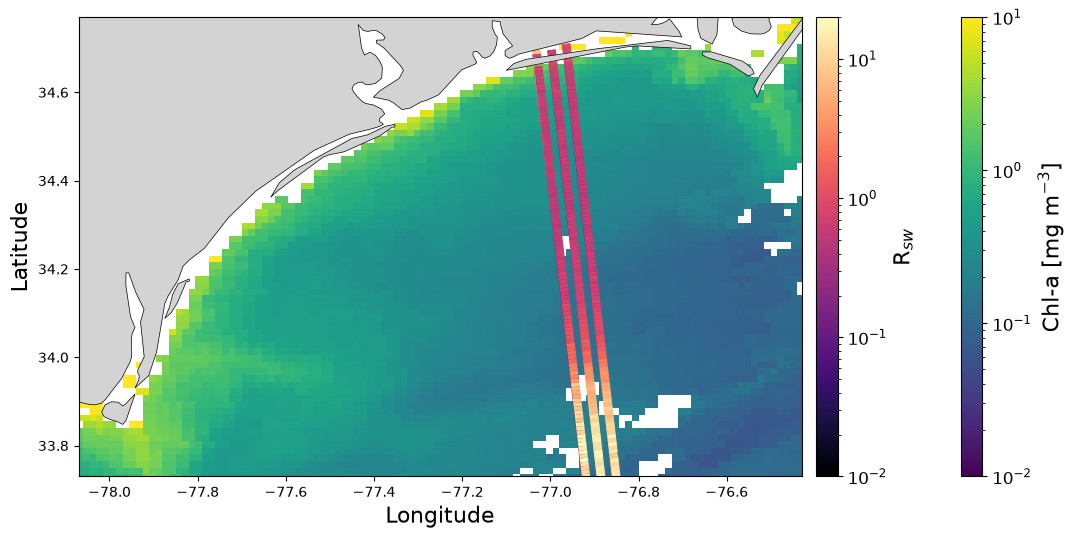

/Users/hmann/Library/CloudStorage/OneDrive-BowdoinCollege/Documents/NASA_SARP/SARP26/aux_fx.py:168: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'longitude' ('longitude',) The recommendation is to set join explicitly for this case.
  combined = xr.concat(gridded_list, dim="swath")


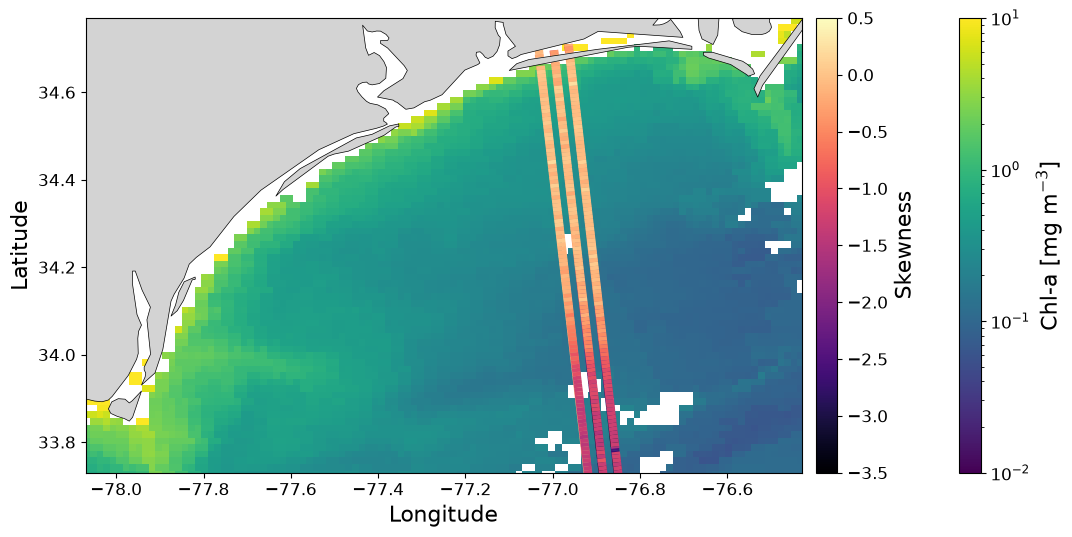

/Users/hmann/Library/CloudStorage/OneDrive-BowdoinCollege/Documents/NASA_SARP/SARP26/aux_fx.py:168: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'longitude' ('longitude',) The recommendation is to set join explicitly for this case.
  combined = xr.concat(gridded_list, dim="swath")


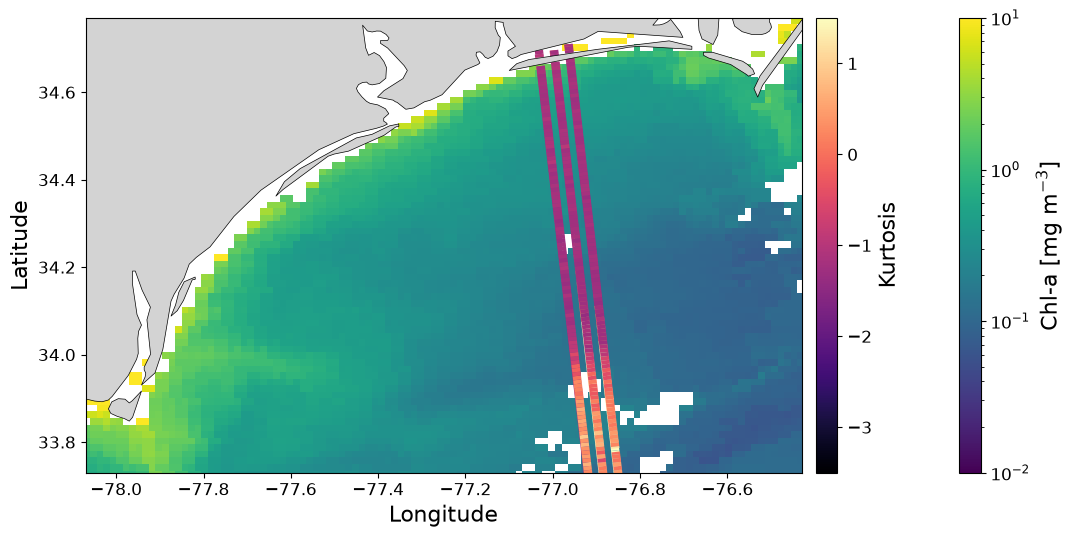

/Users/hmann/Library/CloudStorage/OneDrive-BowdoinCollege/Documents/NASA_SARP/SARP26/aux_fx.py:168: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'longitude' ('longitude',) The recommendation is to set join explicitly for this case.
  combined = xr.concat(gridded_list, dim="swath")


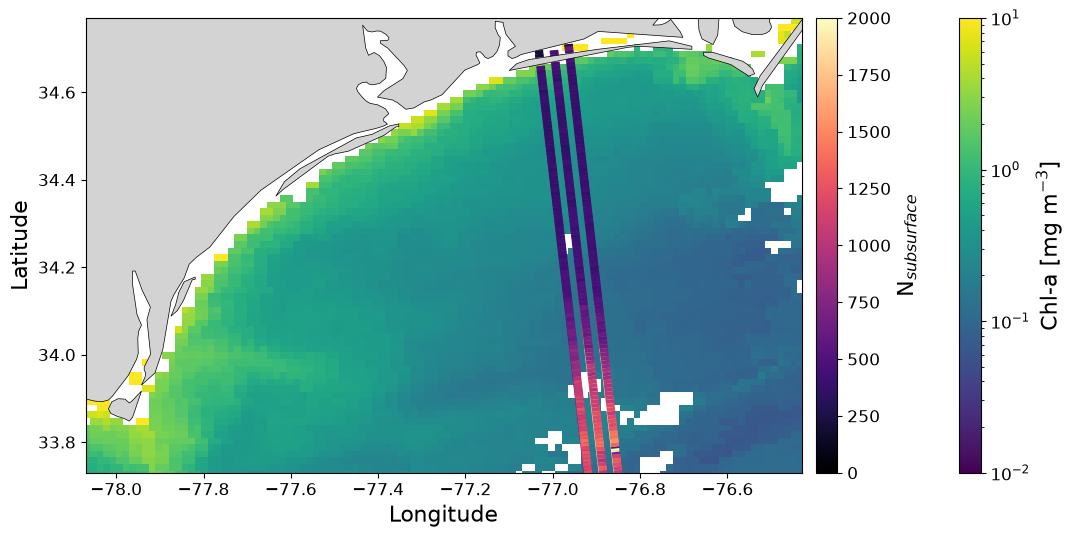

In [12]:
from aux_fx import ATLAS_overlays
import matplotlib.colors as colors
from matplotlib.colors import LogNorm

resolution = (0.015, 0.015)
date_array = ["2024-06-29"]
matchup_df_day = matchup_df[
    pd.to_datetime(matchup_df['date']).dt.strftime("%Y-%m-%d") == date_array[0]
]

pLAT_MIN = 33.70
pLAT_MAX = 34.80
pLON_MIN = -78.10
pLON_MAX = -76.40

params = (pLAT_MIN, pLAT_MAX, pLON_MIN, pLON_MAX, resolution, date_array)

"""R_sw"""
variable = "R_sw"
label = "R$_{sw}$"
# vmin = matchup_df_day[variable].quantile(0.03)
# vmax = matchup_df_day[variable].quantile(0.97)
norm_col = LogNorm(vmin=0.01, vmax=20)
filename = "FINAL_FIGS/RSW_NC.png"
ATLAS_overlays(matchup_df, variable, label, norm_col, filename, params)


""" Skewness """
variable = "skewness"
label = "Skewness"
filename = "FINAL_FIGS/Skew_NC.png"
vmin = matchup_df_day[variable].quantile(0.03)
vmax = matchup_df_day[variable].quantile(0.97)

norm_col = colors.Normalize(vmin=-3.5, vmax=0.5, clip=True)

ATLAS_overlays(matchup_df, variable, label, norm_col, filename, params)


""" Kurtosis """
variable = "kurtosis"
label = "Kurtosis"
filename = "FINAL_FIGS/Kurt_NC.png"
norm_col = colors.Normalize(vmin=-3.5, vmax=1.5)
# vmin = matchup_df_day[variable].quantile(0.05)
# vmax = matchup_df_day[variable].quantile(0.95)

# norm_col = colors.Normalize(vmin=vmin, vmax=vmax, clip=True)
ATLAS_overlays(matchup_df, variable, label, norm_col, filename, params)

"""N_sub"""
variable = "N_subsurface"
label = "N$_{subsurface}$"
norm_col = colors.Normalize(vmin=0, vmax=2000)
# vmin = matchup_df_day[variable].quantile(0.05)
# vmax = matchup_df_day[variable].quantile(0.95)

# norm_col = colors.Normalize(vmin=vmin, vmax=vmax, clip=True)
filename = "FINAL_FIGS/Nsub_NC.png"

ATLAS_overlays(matchup_df, variable, label, norm_col, filename, params)